<a href="https://colab.research.google.com/github/aditi-tawade-ai/SkillBuilding/blob/main/Notebook/SVM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# importing libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# import dataset
path = '/content/pulsar_stars.csv'
df = pd.read_csv(path)
df[:2]

,Mean of the integrated profile,Standard deviation of the integrated profile,Excess kurtosis of the integrated profile,Skewness of the integrated profile,Mean of the DM-SNR curve,Standard deviation of the DM-SNR curve,Excess kurtosis of the DM-SNR curve,Skewness of the DM-SNR curve,target_class
0,140.562500,55.683782,-0.234571,-0.699648,3.199833,19.110426,7.975532,74.242225,0
1,102.507812,58.882430,0.465318,-0.515088,1.677258,14.860146,10.576487,127.393580,0


#Data Analysis

In [3]:
df.shape

(17898, 9)

In [4]:
df.columns

Index([' Mean of the integrated profile',
       ' Standard deviation of the integrated profile',
       ' Excess kurtosis of the integrated profile',
       ' Skewness of the integrated profile', ' Mean of the DM-SNR curve',
       ' Standard deviation of the DM-SNR curve',
       ' Excess kurtosis of the DM-SNR curve', ' Skewness of the DM-SNR curve',
       'target_class'],
      dtype='object')

In [5]:
# removing leading spaces from the column names
df.columns = df.columns.str.strip()
df.columns

Index(['Mean of the integrated profile',
       'Standard deviation of the integrated profile',
       'Excess kurtosis of the integrated profile',
       'Skewness of the integrated profile', 'Mean of the DM-SNR curve',
       'Standard deviation of the DM-SNR curve',
       'Excess kurtosis of the DM-SNR curve', 'Skewness of the DM-SNR curve',
       'target_class'],
      dtype='object')

In [6]:
# renaming the column names
df.columns = ['IP_mean','IP_sd','IP_kurtosis','IP_skewness','DM-SNR_mean',
              'DM-SNR_sd','DM-SNR_kurtosis','DM-SNR_skewness','target_class']

In [7]:
df.columns

Index(['IP_mean', 'IP_sd', 'IP_kurtosis', 'IP_skewness', 'DM-SNR_mean',
       'DM-SNR_sd', 'DM-SNR_kurtosis', 'DM-SNR_skewness', 'target_class'],
      dtype='object')

In [8]:
# checking unique values in target column
df['target_class'].unique()

array([0, 1])

In [9]:
# checking distribution
df['target_class'].value_counts()

,count
target_class,
0,16259
1,1639


In [10]:
# checking in percentile
df['target_class'].value_counts()/float(len(df))

,count
target_class,
0,0.908426
1,0.091574


From above we can observe that the data is imbalanced

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17898 entries, 0 to 17897
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   IP_mean          17898 non-null  float64
 1   IP_sd            17898 non-null  float64
 2   IP_kurtosis      17898 non-null  float64
 3   IP_skewness      17898 non-null  float64
 4   DM-SNR_mean      17898 non-null  float64
 5   DM-SNR_sd        17898 non-null  float64
 6   DM-SNR_kurtosis  17898 non-null  float64
 7   DM-SNR_skewness  17898 non-null  float64
 8   target_class     17898 non-null  int64  
dtypes: float64(8), int64(1)
memory usage: 1.2 MB


In [12]:
# checkin if there are any missing values
df.isna().sum()

,0
IP_mean,0
IP_sd,0
IP_kurtosis,0
IP_skewness,0
DM-SNR_mean,0
DM-SNR_sd,0
DM-SNR_kurtosis,0
DM-SNR_skewness,0
target_class,0


we can see that there are no missing values

In [13]:
# finding outliers
df.describe().T

,count,mean,std,min,25%,50%,75%,max
IP_mean,17898.0,111.079968,25.652935,5.812500,100.929688,115.078125,127.085938,192.617188
IP_sd,17898.0,46.549532,6.843189,24.772042,42.376018,46.947479,51.023202,98.778911
IP_kurtosis,17898.0,0.477857,1.064040,-1.876011,0.027098,0.223240,0.473325,8.069522
IP_skewness,17898.0,1.770279,6.167913,-1.791886,-0.188572,0.198710,0.927783,68.101622
DM-SNR_mean,17898.0,12.614400,29.472897,0.213211,1.923077,2.801839,5.464256,223.392141
DM-SNR_sd,17898.0,26.326515,19.470572,7.370432,14.437332,18.461316,28.428104,110.642211
DM-SNR_kurtosis,17898.0,8.303556,4.506092,-3.139270,5.781506,8.433515,10.702959,34.539844
DM-SNR_skewness,17898.0,104.857709,106.514540,-1.976976,34.960504,83.064556,139.309330,1191.000837
target_class,17898.0,0.091574,0.288432,0.000000,0.000000,0.000000,0.000000,1.000000


<Axes: >

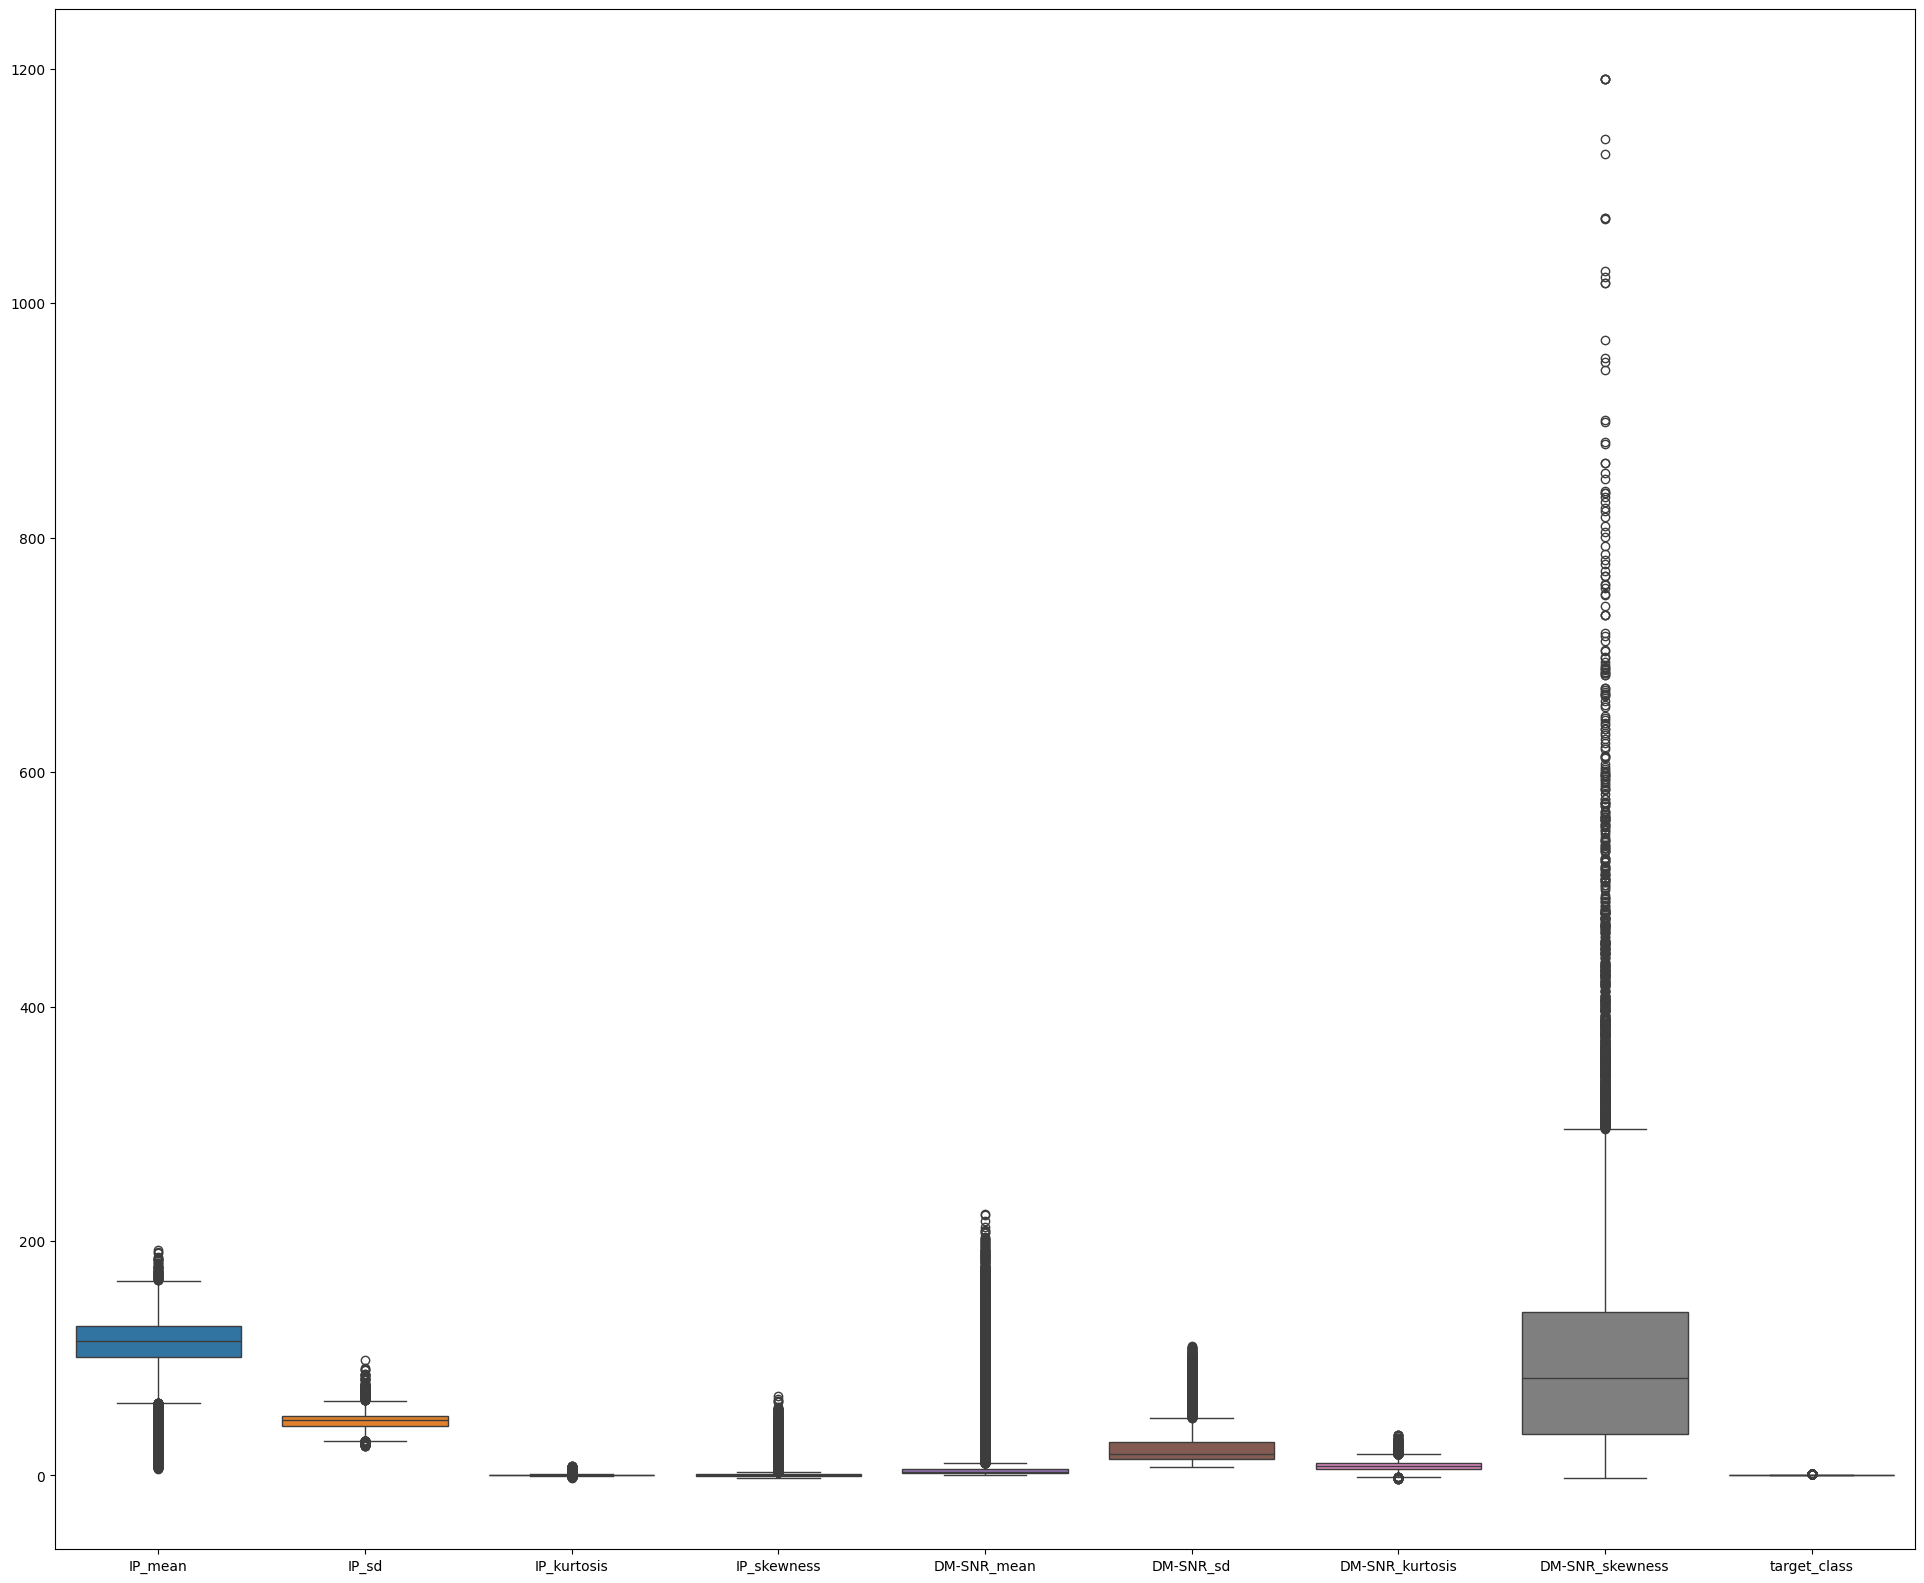

In [14]:
# we'll plot the outliers
plt.figure(figsize=(24,20))
sns.boxplot(df)

- We can see that there are a lot of outliers in the data
- But here we will use soft margine though it does not handels the outliers it tolerrates the outliers using C parameter by keeping it Low c


Text(0, 0.5, 'Number of pulsar stars')

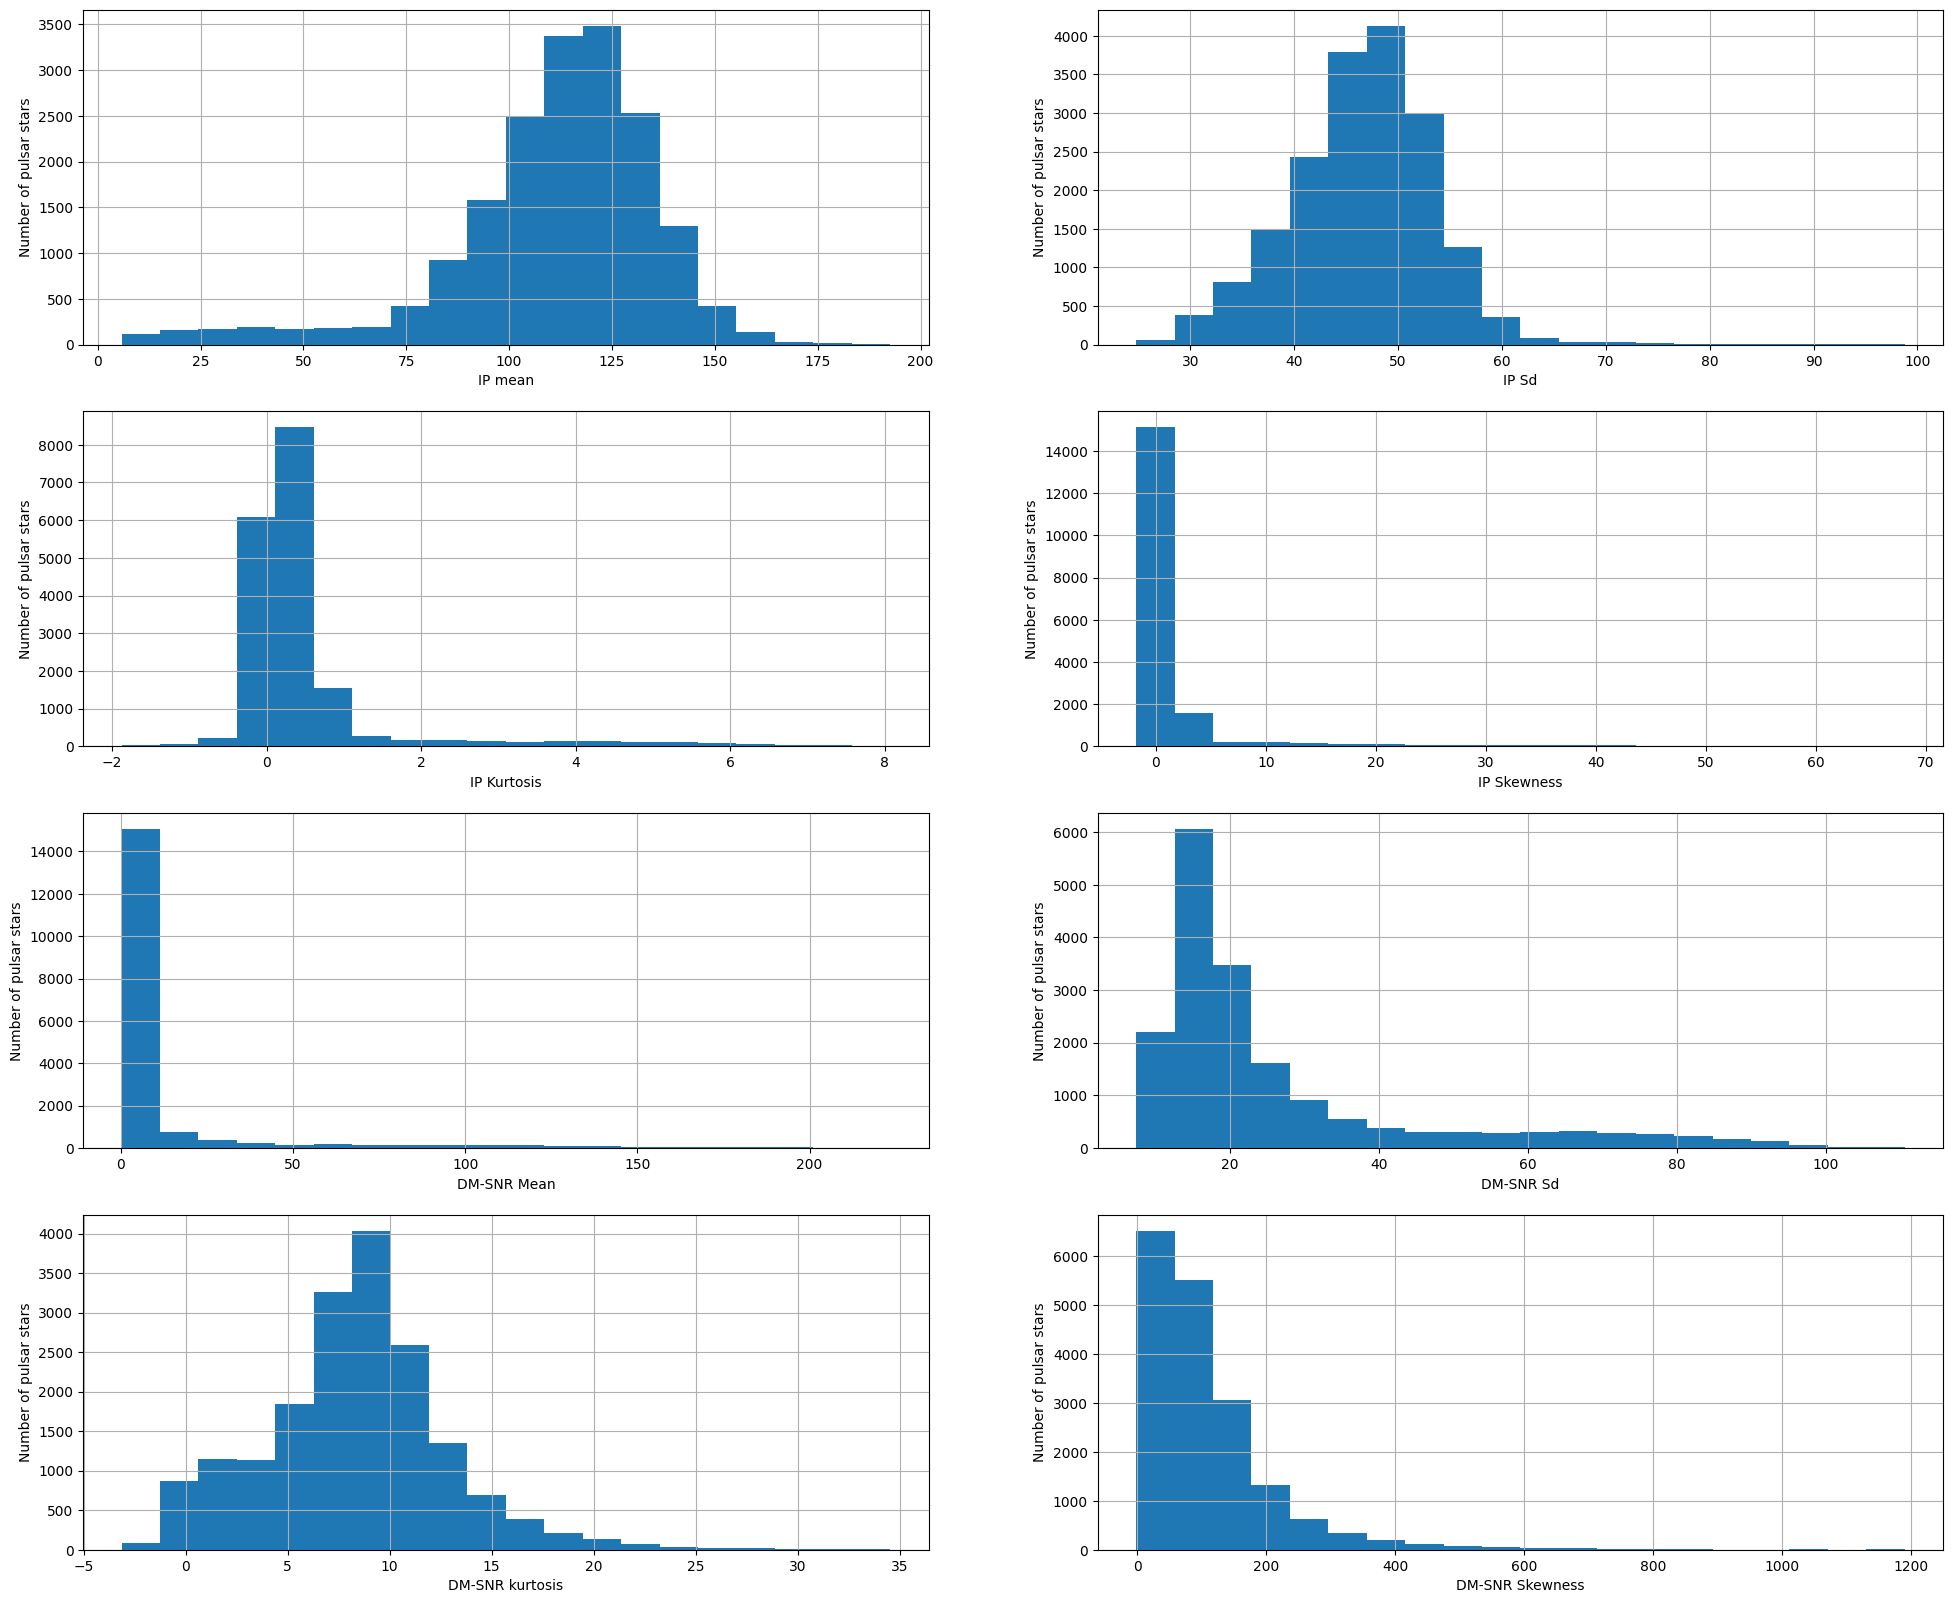

In [15]:
plt.figure(figsize=(24,20))


plt.subplot(4, 2, 1)
fig = df['IP_mean'].hist(bins=20)
fig.set_xlabel('IP mean')
fig.set_ylabel('Number of pulsar stars')


plt.subplot(4, 2, 2)
fig = df['IP_sd'].hist(bins=20)
fig.set_xlabel('IP Sd')
fig.set_ylabel('Number of pulsar stars')

plt.subplot(4, 2, 3)
fig = df['IP_kurtosis'].hist(bins=20)
fig.set_xlabel('IP Kurtosis')
fig.set_ylabel('Number of pulsar stars')



plt.subplot(4, 2, 4)
fig = df['IP_skewness'].hist(bins=20)
fig.set_xlabel('IP Skewness')
fig.set_ylabel('Number of pulsar stars')



plt.subplot(4, 2, 5)
fig = df['DM-SNR_mean'].hist(bins=20)
fig.set_xlabel('DM-SNR Mean')
fig.set_ylabel('Number of pulsar stars')

plt.subplot(4, 2, 6)
fig = df['DM-SNR_sd'].hist(bins=20)
fig.set_xlabel('DM-SNR Sd')
fig.set_ylabel('Number of pulsar stars')



plt.subplot(4, 2, 7)
fig = df['DM-SNR_kurtosis'].hist(bins=20)
fig.set_xlabel('DM-SNR kurtosis')
fig.set_ylabel('Number of pulsar stars')


plt.subplot(4, 2, 8)
fig = df['DM-SNR_skewness'].hist(bins=20)
fig.set_xlabel('DM-SNR Skewness')
fig.set_ylabel('Number of pulsar stars')



so the data distribution is not symetric or is skewed

In [16]:
# seperating data
X  = df.drop(['target_class'],axis=1)
y = df['target_class']

In [17]:
# training and testing
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [18]:
X_train.shape , X_test.shape

((14318, 8), (3580, 8))

In [19]:
# feature scaling
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [20]:
X_train = pd.DataFrame(X_train,columns=X.columns)
X_test = pd.DataFrame(X_test,columns=X.columns)

In [21]:
X_train.describe().T

,count,mean,std,min,25%,50%,75%,max
IP_mean,14318.0,-8.833399e-17,1.000035,-4.105247,-0.400789,0.159952,0.623352,3.179668
IP_sd,14318.0,7.143639e-16,1.000035,-3.185842,-0.611926,0.058482,0.651588,7.645531
IP_kurtosis,14318.0,2.431666e-17,1.000035,-2.217175,-0.425302,-0.239537,-0.005006,7.151513
IP_skewness,14318.0,-2.431666e-17,1.000035,-0.578561,-0.317878,-0.254499,-0.135996,10.787458
DM-SNR_mean,14318.0,3.176054e-17,1.000035,-0.419908,-0.362401,-0.332546,-0.243673,7.119315
DM-SNR_sd,14318.0,2.828673e-17,1.000035,-0.969468,-0.608410,-0.401745,0.101820,4.326040
DM-SNR_kurtosis,14318.0,-3.674793e-16,1.000035,-2.530626,-0.558566,0.023284,0.528416,5.784920
DM-SNR_skewness,14318.0,-1.523513e-16,1.000035,-0.997442,-0.652125,-0.208691,0.318809,10.062976


In [22]:
# importing svc with default parameter with kernal = rbf and c = 1
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

In [23]:
svm = SVC()
svm.fit(X_train,y_train)

SVC()

In [24]:
# predict / test
y_pred = svm.predict(X_test)
y_pred

array([0, 1, 0, ..., 0, 0, 1])

In [25]:
# checking accuracy
print('Models accuracy score is:',accuracy_score(y_test,y_pred))

Models accuracy score is: 0.979608938547486


score is 97% with defaullt kernal

In [26]:
# svm with rbf and c = 100
svm=SVC(C=100)
svm.fit(X_train,y_train)


SVC(C=100)

In [78]:
y_pred_rbf = svm.predict(X_test)
y_pred_rbf

array([0, 1, 0, ..., 0, 0, 1])

In [79]:
print('Models accuracy score with c=100 is:',accuracy_score(y_test,y_pred_rbf))

Models accuracy score with c=100 is: 0.9801675977653631


we can see that the accuracy is increased with increase in c value means higher c value less outliers

In [29]:
# lets check with c=1000
svm=SVC(C=1000)
svm.fit(X_train,y_train)

SVC(C=1000)

In [30]:
y_pred = svm.predict(X_test)


In [31]:
print('Models accuracy score with c=1000 is:',accuracy_score(y_test,y_pred))

Models accuracy score with c=1000 is: 0.9801675977653631


model accuracy is decreased

# SVM with linear kernal

In [32]:
lnr_svm = SVC(kernel='linear')
lnr_svm.fit(X_train,y_train)

SVC(kernel='linear')

In [33]:
y_pred_lr = lnr_svm.predict(X_test)

In [34]:
print('Models accuracy score with linear kernal is:',accuracy_score(y_test,y_pred_lr))

Models accuracy score with linear kernal is: 0.9787709497206704


In [35]:
lnr_svm = SVC(kernel='linear',C=100)
lnr_svm.fit(X_train,y_train)

SVC(C=100, kernel='linear')

In [36]:
y_pred_lr = lnr_svm.predict(X_test)

In [37]:
print('Models accuracy score with linear kernal and c=100 is:',accuracy_score(y_test,y_pred_lr))

Models accuracy score with linear kernal and c=100 is: 0.979050279329609


In [38]:
lnr_svm = SVC(kernel='linear',C=1000)
lnr_svm.fit(X_train,y_train)

SVC(C=1000, kernel='linear')

In [39]:
y_pred_lr = lnr_svm.predict(X_test)

In [40]:
print('Models accuracy score with linear kernal and c=1000 is:',accuracy_score(y_test,y_pred_lr))

Models accuracy score with linear kernal and c=1000 is: 0.979050279329609


here accuracy for c=1 is higher for linear kernel

In [43]:
# check accuracy for test and train data for overfitting
y_pred_train = lnr_svm.predict(X_train)

In [44]:
print('Training-set accuracy score: {0:0.4f}'. format(accuracy_score(y_train, y_pred_train)))

Training-set accuracy score: 0.9794


In [45]:
print('Test-set accuracy score: {0:0.4f}'. format(accuracy_score(y_test, y_pred)))

Test-set accuracy score: 0.9802


this is the score for training data and testing data we can see it is similar so there is no overfiting

In [46]:
# check class distribution
y_test.value_counts()

,count
target_class,
0,3259
1,321


for calculating null accuracy we need need to divide the most frequent class with total occurance

In [47]:
null_acc = y_test.value_counts().head(1)/len(y_test)
# 3259/(3259+321)
print('Null accuracy score is:',null_acc)

Null accuracy score is: target_class
0    0.910335
Name: count, dtype: float64


so our model is doing quite well in predicting most frequent classes

# SVM using polynomial kernel

In [48]:
poly = SVC(kernel='poly')
poly.fit(X_train,y_train)

SVC(kernel='poly')

In [50]:
y_pred = poly.predict(X_test)

In [51]:
print('Models accuracy score is:',accuracy_score(y_test,y_pred))

Models accuracy score is: 0.9784916201117319


increasing c =100

In [52]:
poly = SVC(kernel='poly',C=100)
poly.fit(X_train,y_train)

SVC(C=100, kernel='poly')

In [53]:
y_pred = poly.predict(X_test)

In [54]:
print('Models accuracy score with c=100 is:',accuracy_score(y_test,y_pred))

Models accuracy score with c=100 is: 0.9804469273743017


we can see that the sore is increased now taking c=1000

In [55]:
poly = SVC(kernel='poly',C=1000)
poly.fit(X_train,y_train)

SVC(C=1000, kernel='poly')

In [56]:
y_pred = poly.predict(X_test)

In [57]:
print('Models accuracy score with c=1000 is:',accuracy_score(y_test,y_pred))

Models accuracy score with c=1000 is: 0.9810055865921787


it is good than c=100

In [58]:
# checking overfiting
y_pred_train = poly.predict(X_train)

In [59]:
print('Training-set accuracy score: {0:0.4f}'. format(accuracy_score(y_train, y_pred_train)))

Training-set accuracy score: 0.9814


In [60]:
print('testing-set accuracy score:{0:0.4f}'.format(accuracy_score(y_test,y_pred)))

testing-set accuracy score:0.9810


values are similar so no issue of overfiting

# SVM using sigmoid kernel

In [61]:
smg = SVC(kernel='sigmoid')
smg.fit(X_train,y_train)

SVC(kernel='sigmoid')

In [62]:
y_pred = smg.predict(X_test)

In [63]:
print('Accuracy score for sigmoid is:',accuracy_score(y_test,y_pred))

Accuracy score for sigmoid is: 0.8751396648044693


now taking c= 100

In [64]:
smg = SVC(kernel='sigmoid',C=100)
smg.fit(X_train,y_train)

SVC(C=100, kernel='sigmoid')

In [65]:
y_pred = smg.predict(X_test)

In [66]:
print('Accuracy score with c=100 for sigmoid:',accuracy_score(y_test,y_pred))

Accuracy score with c=100 for sigmoid: 0.8748603351955307


In [67]:
smg = SVC(kernel='sigmoid',C=1000)
smg.fit(X_train,y_train)

SVC(C=1000, kernel='sigmoid')

In [68]:
y_pred = smg.predict(X_test)

In [69]:
print('Accuracy score c=1000 for sigmoid is:',accuracy_score(y_test,y_pred))

Accuracy score c=1000 for sigmoid is: 0.8748603351955307


we can see that sigmoid kernel is performing poor just like polynomial

since rbf and linear kernel is performing better we will go with either of these 2

# **Confusion matrix with RBF**

In [81]:
from sklearn.metrics import confusion_matrix,classification_report
cm = confusion_matrix(y_test,y_pred_rbf)
cm

array([[3239,   20],
       [  51,  270]])

Text(50.722222222222214, 0.5, 'Predicted')

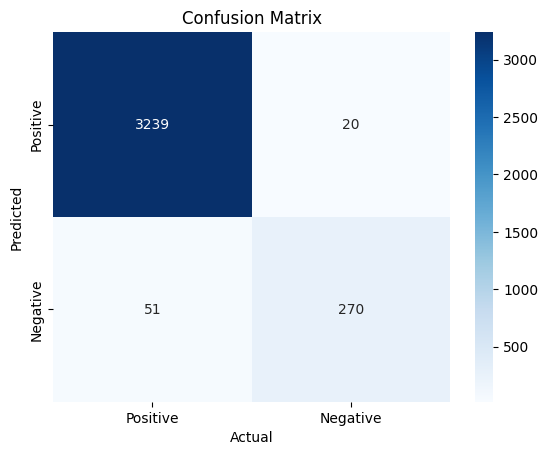

In [82]:
# ploting with graph
cm_mat = pd.DataFrame(data=cm,columns=['Positive','Negative'],index=['Positive','Negative'])

sns.heatmap(cm_mat,annot=True,fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Actual')
plt.ylabel('Predicted')

# Classification report

In [80]:
print(classification_report(y_test,y_pred_rbf))

              precision    recall  f1-score   support

           0       0.98      0.99      0.99      3259
           1       0.93      0.84      0.88       321

    accuracy                           0.98      3580
   macro avg       0.96      0.92      0.94      3580
weighted avg       0.98      0.98      0.98      3580



now we have choosed the RBF as a best model with good classification report now next step is forming pickle file and deployment